# 06 · Regression: predicting Feature J from C plus two uncorrelated supporting features

Data: every show in **both** files where J was observed (930 shows); 80/20 random split (Train 744 / Test 186), 10-fold CV on Train. The 70 shows whose J was reconstructed in cleaning are kept aside as an extra check.

1. **Supporting features.** Two routes, both on the Train split:
   * *as measured*: pairs where C, X1, X2 are mutually uncorrelated as recorded (|r| < 0.10, p ≥ 0.05);
   * *orthogonalised* (chosen): any pair, made exactly uncorrelated with C and with each other by sequential residualisation (X1' = X1 − fit on C; X2' = X2 − fit on C and X1'), fitted on Train only.
   The pair with the lowest CV RMSE wins in each route.
2. **Models** on C + X1' + X2': OLS, polynomial (degree by CV), cubic spline + ridge, SVR-RBF and XGBoost (RandomizedSearchCV). Metrics: MSE, RMSE, MAE, adjusted R², Train vs Test. Best = lowest CV RMSE with the one-standard-error rule.

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/tv-genre-classification


In [2]:
# Rebuild the cleaned data if it is missing (fresh clone)
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()
from src.models import regression_j as rj
out = rj.run(); plt.close("all")
print("as measured:", out["raw_support"], "| orthogonalised (chosen):", out["support"], "| best model:", out["best"])

13:25:57 | INFO    | src.models.regression_j | Uncorrelated as measured: ['G', 'M'] | orthogonalised pair (chosen): ['B', 'M']


13:26:18 | INFO    | src.models.regression_j | Regression comparison:
               Model     Features  Train_RMSE  Test_RMSE  Test_MSE  Test_MAE  Train_Adj_R2  Test_Adj_R2  CV10_RMSE
0       OLS (C only)            C      1.3530     1.3982    1.9551    1.0782        0.1183      -0.0103     1.3461
1  OLS (as measured)    C + G + M      1.3461     1.3972    1.9522    1.0742        0.1249      -0.0199     1.3428
2         OLS linear  C + B' + M'      0.2892     0.2744    0.0753    0.2184        0.9596       0.9607     0.2889
3         Polynomial  C + B' + M'      0.2567     0.2627    0.0690    0.2030        0.9682       0.9639     0.2686
4       Cubic spline  C + B' + M'      0.2706     0.2793    0.0780    0.2174        0.9646       0.9592     0.2854
5            SVR-RBF  C + B' + M'      0.2735     0.2808    0.0788    0.2248        0.9639       0.9588     0.2776
6            XGBoost  C + B' + M'      0.2476     0.3197    0.1022    0.2391        0.9704       0.9466     0.3309


13:26:18 | INFO    | src.models.regression_j | Best (1-SE rule): Polynomial (lowest CV RMSE: Polynomial) | VIF as measured {'C': 5.39, 'B': 11.2, 'M': 7.17} -> {'C': 1.0, 'B': 1.0, 'M': 1.0} | correlation:
   split  max_abs_r_as_measured  max_abs_r_orthogonalised
0  Train                 0.7207                    0.0000
1   Test                 0.7624                    0.1157


as measured: ['G', 'M'] | orthogonalised (chosen): ['B', 'M'] | best model: Polynomial


## 1. Supporting-feature search

,X1,X2,r_C_X1,r_C_X2,r_X1_X2,max_abs_r,min_p,uncorrelated_as_measured,cv_rmse_ols
0,B,M,0.6008,-0.0338,0.7207,0.7207,0.0,False,0.2889
1,I,N,0.2865,-0.5346,-0.8104,0.8104,0.0,False,0.4198
2,L,N,0.5054,-0.5346,-0.6029,0.6029,0.0,False,0.6103
3,B,L,0.6008,0.5054,-0.0253,0.6008,0.0,False,1.0129
4,M,N,-0.0338,-0.5346,0.1526,0.5346,0.0,False,1.1197
5,A,N,0.1159,-0.5346,0.0554,0.5346,0.0,False,1.1199
6,B,N,0.6008,-0.5346,-0.0843,0.6008,0.0,False,1.1419
7,E,N,0.0329,-0.5346,0.0151,0.5346,0.0,False,1.1475
8,N,O,-0.5346,-0.0093,0.0007,0.5346,0.0,False,1.1475
9,H,N,0.0152,-0.5346,0.0141,0.5346,0.0,False,1.1479


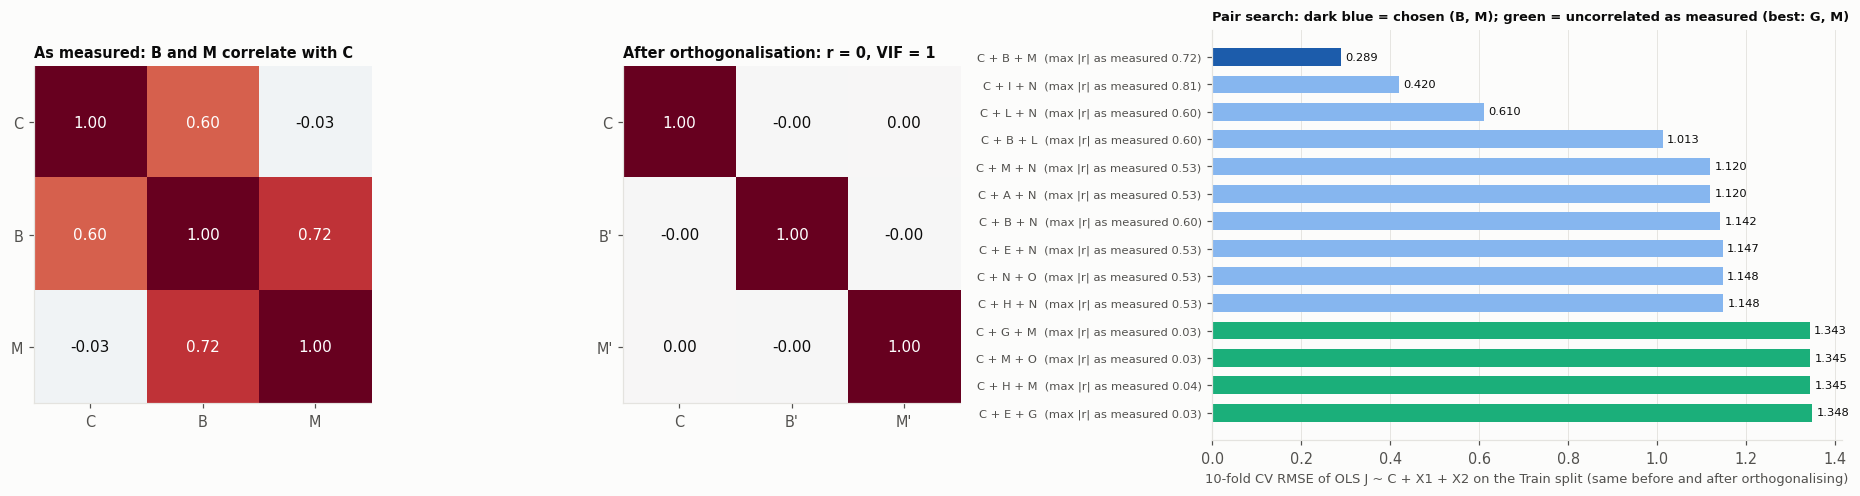

In [3]:
obs, rec, lab = rj.regression_data()
from sklearn.model_selection import train_test_split
tr, te = train_test_split(obs, test_size=.2, random_state=cfg.RANDOM_STATE)
rj.plot_screening(tr, out["screening"], out["raw_support"], out["support"], out["orthogonalizer"])
out["screening"].head(10).round(4)

In [4]:
out["screening"][out["screening"].uncorrelated_as_measured].head(6).round(4)

,X1,X2,r_C_X1,r_C_X2,r_X1_X2,max_abs_r,min_p,uncorrelated_as_measured,cv_rmse_ols
30,G,M,0.0088,-0.0338,0.0222,0.0338,0.3569,True,1.3428
33,M,O,-0.0338,-0.0093,0.0166,0.0338,0.3569,True,1.3448
34,H,M,0.0152,-0.0338,0.0395,0.0395,0.2823,True,1.3448
35,E,G,0.0329,0.0088,-0.0181,0.0329,0.3709,True,1.3483
39,E,O,0.0329,-0.0093,-0.0220,0.0329,0.3709,True,1.3501
40,G,H,0.0088,0.0152,0.0380,0.0380,0.3006,True,1.3502


In [5]:
out["correlation"].round(4)

,split,max_abs_r_as_measured,max_abs_r_orthogonalised
0,Train,0.7207,0.0000
1,Test,0.7624,0.1157


Features that are uncorrelated with C **as measured** (E, G, H, M, O) carry almost nothing about J: the best such pair (G, M) lowers CV RMSE only from 1.346 to 1.343. The information about J that C lacks sits in B, I, L, N, which are all correlated with C. Orthogonalising B and M against C keeps exactly that extra information while making the three predictors uncorrelated (r = 0 on Train, |r| ≤ 0.12 on Test; VIF 11.2 → 1.0).

## 2. Model comparison (Train vs Test)

In [6]:
cols = ["Model", "Features"] + [f"{s}_{m}" for s in ["Train", "Test"] for m in ["MSE", "RMSE", "MAE", "Adj_R2"]] + ["CV10_RMSE", "CV10_RMSE_SE"]
out["comparison"][cols].round(4)

,Model,Features,Train_MSE,Train_RMSE,Train_MAE,Train_Adj_R2,Test_MSE,Test_RMSE,Test_MAE,Test_Adj_R2,CV10_RMSE,CV10_RMSE_SE
0,OLS (C only),C,1.8306,1.3530,1.0720,0.1183,1.9551,1.3982,1.0782,-0.0103,1.3461,0.0494
1,OLS (as measured),C + G + M,1.8121,1.3461,1.0673,0.1249,1.9522,1.3972,1.0742,-0.0199,1.3428,0.0484
2,OLS linear,C + B' + M',0.0836,0.2892,0.2282,0.9596,0.0753,0.2744,0.2184,0.9607,0.2889,0.0107
3,Polynomial,C + B' + M',0.0659,0.2567,0.2039,0.9682,0.0690,0.2627,0.2030,0.9639,0.2686,0.0094
4,Cubic spline,C + B' + M',0.0732,0.2706,0.2150,0.9646,0.0780,0.2793,0.2174,0.9592,0.2854,0.0125
5,SVR-RBF,C + B' + M',0.0748,0.2735,0.2236,0.9639,0.0788,0.2808,0.2248,0.9588,0.2776,0.0090
6,XGBoost,C + B' + M',0.0613,0.2476,0.1858,0.9704,0.1022,0.3197,0.2391,0.9466,0.3309,0.0217


In [7]:
print("polynomial CV RMSE by degree:", {k: round(v, 4) for k, v in out["info"]["poly_cv_rmse_by_degree"].items()})
print("spline CV RMSE by knots:", {k: round(v, 4) for k, v in out["info"]["spline_cv_rmse_by_knots"].items()})

polynomial CV RMSE by degree: {1: np.float64(0.2889), 2: np.float64(0.2714), 3: np.float64(0.2686), 4: np.float64(0.3038)}
spline CV RMSE by knots: {3: np.float64(0.2865), 4: np.float64(0.2869), 5: np.float64(0.2854), 6: np.float64(0.2865), 8: np.float64(0.2882)}


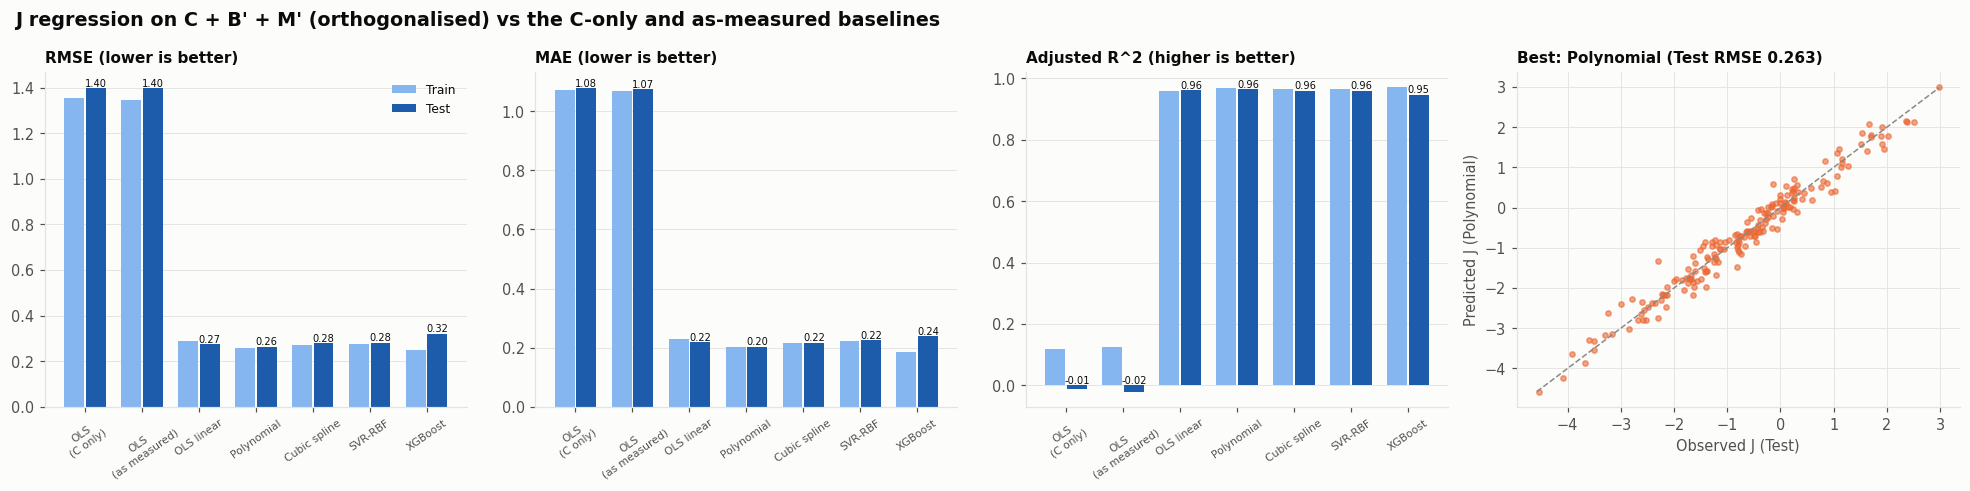

In [8]:
rj.plot_comparison(out["comparison"], out["models"], out["best"], te[out["features"]], te["J"]);

## 3. OLS inference on the orthogonalised predictors

In [9]:
print(out["ols"].summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5795      0.011    -54.152      0.000      -0.601      -0.559
C              0.3939      0.008     46.885      0.000       0.377       0.410
B              0.2898      0.008     34.573      0.000       0.273       0.306
M             -2.6140      0.022   -119.425      0.000      -2.657      -2.571


,coef,se,se_HC3,p,ci_low,ci_high,VIF_orthogonalised,VIF_as_measured,coef_as_measured
B',0.2898,0.0084,0.0133,0.0,0.2733,0.3062,1.0,11.2015,2.7736
C,0.3939,0.0084,0.0085,0.0,0.3774,0.4104,1.0,5.3893,-1.7866
Intercept,-0.5795,0.0107,0.0107,0.0,-0.6005,-0.5585,NaN,NaN,-0.1447
M',-2.6140,0.0219,0.0238,0.0,-2.6570,-2.5711,1.0,7.1663,-2.6140


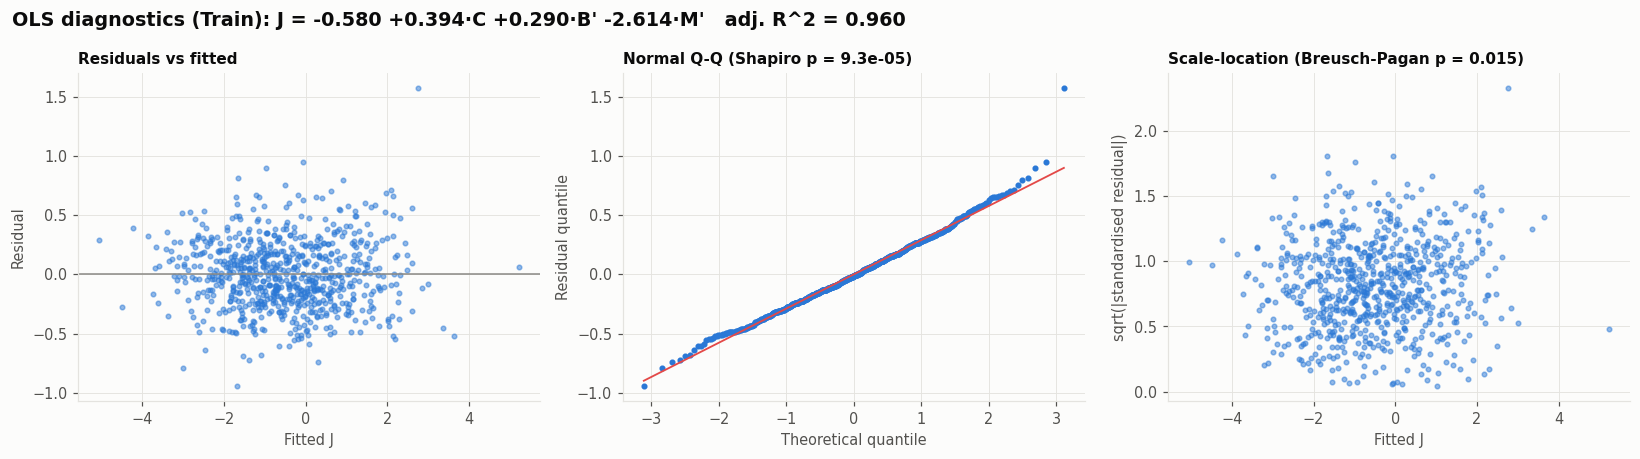

In [10]:
rj.plot_diagnostics(out["ols"], out["breusch_pagan"], out["features"])
out["ols_table"].round(4)

**Interpretation.**
* With orthogonal predictors each coefficient is stable and separately interpretable: C keeps its simple slope (≈ 0.39), and B' and M' add what B and M know beyond C. As measured, the same model has VIFs of 5 to 11 and coefficients of opposite sign (C = −1.79).
* A cubic polynomial on C, B', M' has the lowest CV RMSE and is chosen by the 1-SE rule: Test RMSE ≈ 0.26, MAE ≈ 0.20, adjusted R² ≈ 0.96, against Test RMSE ≈ 1.40 and adjusted R² ≈ −0.01 for C alone. Train and Test agree, so there is no overfitting; XGBoost overfits slightly.

## 4. Secondary context

,model,R2,n,slope
0,"J ~ C (OLS, training file)",0.1020,558,NaN
1,J ~ C x genre (training file),0.2131,558,NaN
2,J ~ C within Comedy,0.2970,345,0.5246
3,J ~ C within Drama,0.0000,117,-0.0085
4,J ~ C within Reality,0.0251,96,-0.2090
5,"J ~ B + C + I + L + M + N (exact identity, Test)",1.0000,186,NaN


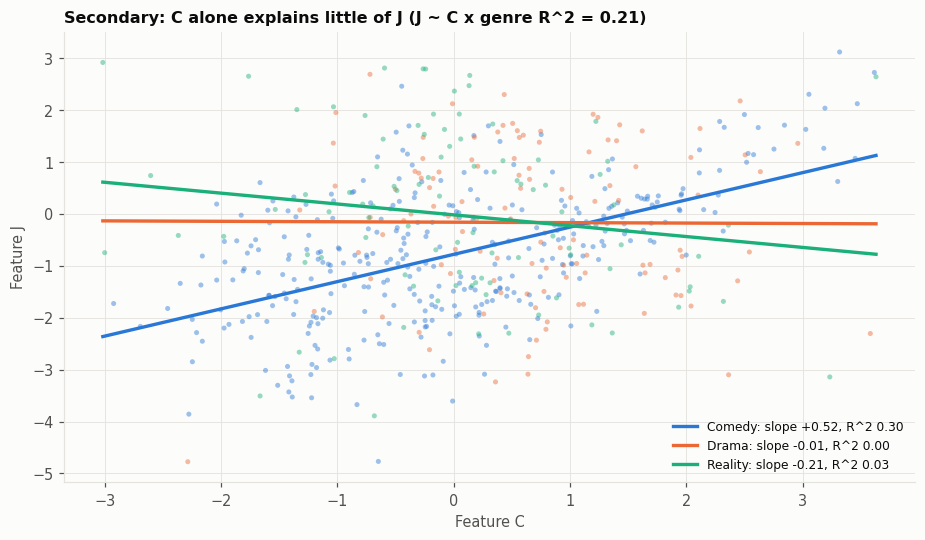

In [11]:
import statsmodels.formula.api as smf
gl = lab[lab.J_was_reconstructed == 0]
rj.plot_genre(gl, {g: smf.ols("J ~ C", data=gl[gl.genre == g]).fit() for g in cfg.CLASSES}, out["interaction"])
out["secondary"].round(4)

J = 0.446·B + 0.337·C + 0.643·I + 0.360·L − 0.282·M + 0.971·N **exactly** (R² = 1.000). If J is needed in production, derive it from these six features; the three-feature model is the best approximation when only C and two supporting features are available.